# Task 3: Advanced Outlier Detection and Treatment

To systematically identify, visualize, evaluate, and appropriately
treat anomalous observations in the university admission dataset using
boxplots, scatterplots, and statistical outlier detection methods.

The analysis aims to distinguish potential data anomalies from valid
extreme observations before machine learning model development.

In [2]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

import warnings
warnings.filterwarnings('ignore')

print("Import Library Successfully")

Import Library Successfully


In [4]:
# Load the dataset 

df = pd.read_csv("Admission_Predict.csv")
print("Dataset load Successfully")

Dataset load Successfully


In [8]:
# Display the First 5 record
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [9]:
# Display the Rows and columns
df.shape

(400, 9)

In [35]:
# Removing the serial no because it's not a applicant feature
numerical_features = df.drop(
    columns=['Serial No.']
).select_dtypes(include=np.number).columns

print("Numerical Features:")
print(list(numerical_features))

analysis_df = df.drop(columns=['Serial No.']).copy()

Numerical Features:
['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA', 'Research', 'Chance of Admit ']


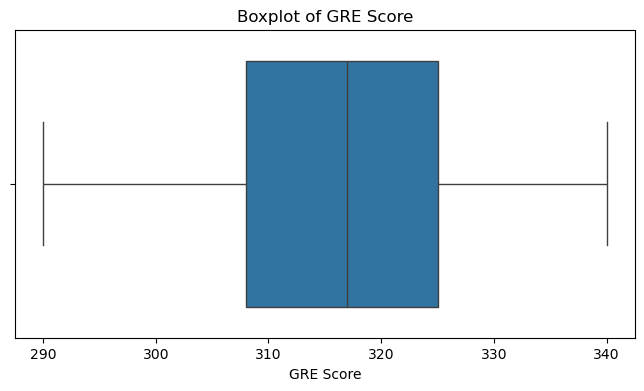

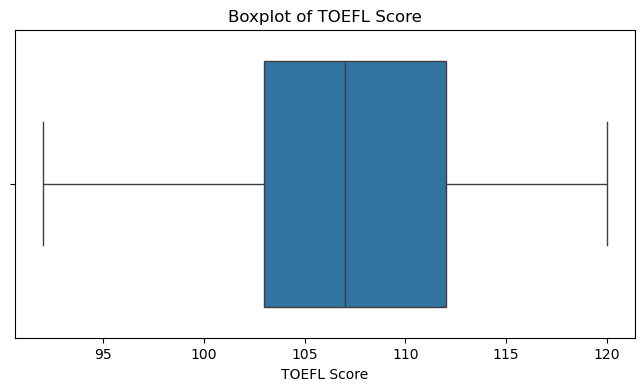

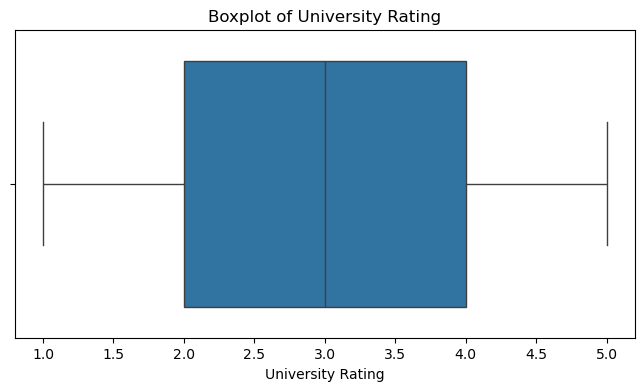

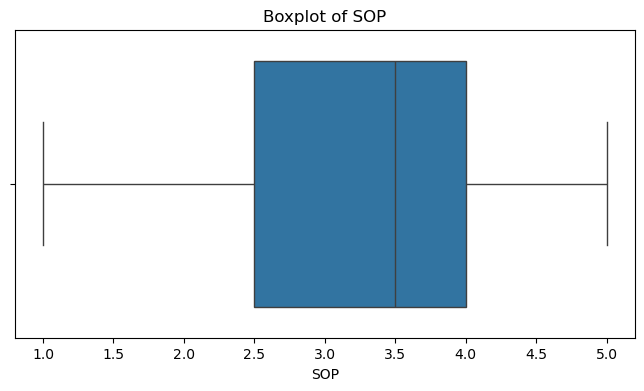

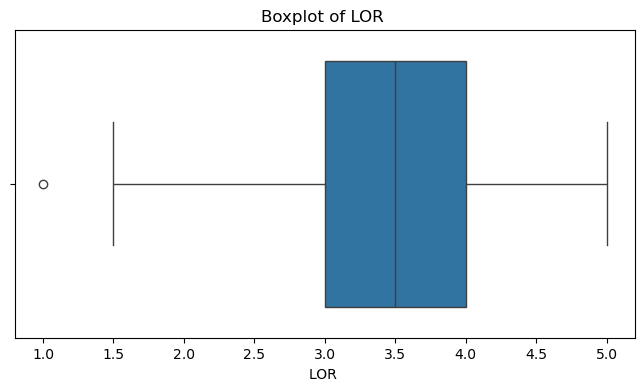

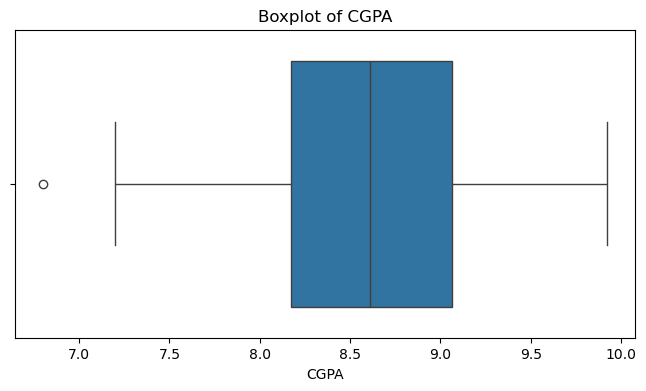

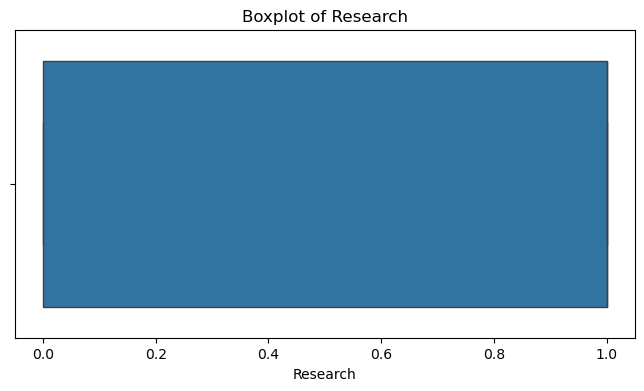

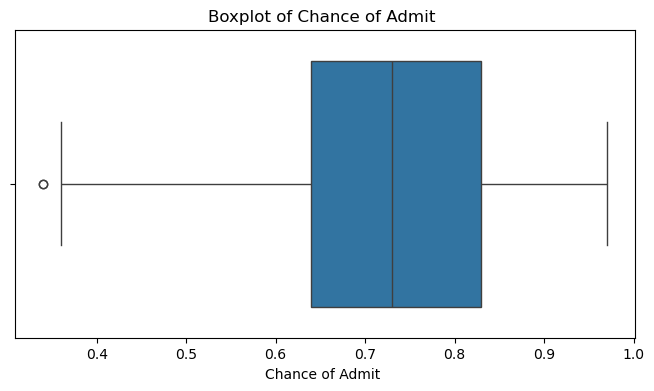

In [16]:
# Boxplot analysis

for column in numerical_features:
    
    plt.figure(figsize=(8, 4))
    
    sns.boxplot(x=analysis_df[column])
    
    plt.title(f'Boxplot of {column}')
    plt.xlabel(column)
    
    plt.show()

In [18]:
# IQR statistical method

outlier_summary = []

for column in numerical_features:
    
    Q1 = analysis_df[column].quantile(0.25)
    Q3 = analysis_df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = analysis_df[
        (analysis_df[column] < lower_bound) |
        (analysis_df[column] > upper_bound)
    ]
    
    outlier_summary.append({
        'Feature': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,GRE Score,308.00,325.0000,17.0000,282.50000,350.50000,0
1,TOEFL Score,103.00,112.0000,9.0000,89.50000,125.50000,0
2,University Rating,2.00,4.0000,2.0000,-1.00000,7.00000,0
3,SOP,2.50,4.0000,1.5000,0.25000,6.25000,0
4,LOR,3.00,4.0000,1.0000,1.50000,5.50000,1
5,CGPA,8.17,9.0625,0.8925,6.83125,10.40125,1
6,Research,0.00,1.0000,1.0000,-1.50000,2.50000,0
7,Chance of Admit,0.64,0.8300,0.1900,0.35500,1.11500,2


In [19]:
# actual outlier records

column = 'CGPA'

Q1 = analysis_df[column].quantile(0.25)
Q3 = analysis_df[column].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

cgpa_outliers = analysis_df[
    (analysis_df[column] < lower) |
    (analysis_df[column] > upper)
]

cgpa_outliers

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
58,300,99,1,3.0,2.0,6.8,1,0.36


In [22]:
# Z-score method

z_scores = np.abs(
    zscore(analysis_df[numerical_features])
)

zscore_outlier_counts = pd.Series(
    (z_scores > 3).sum(axis=0),
    index=numerical_features
)

zscore_outlier_counts

GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 1
Research             0
Chance of Admit      0
dtype: int64

In [24]:
# Compare IQR and Z-score

comparison = pd.DataFrame({
    'IQR Outliers': outlier_summary_df.set_index(
        'Feature'
    )['Outlier Count'],
    
    'Z-Score Outliers': zscore_outlier_counts
})

comparison

,IQR Outliers,Z-Score Outliers
GRE Score,0,0
TOEFL Score,0,0
University Rating,0,0
SOP,0,0
LOR,1,0
CGPA,1,1
Research,0,0
Chance of Admit,2,0


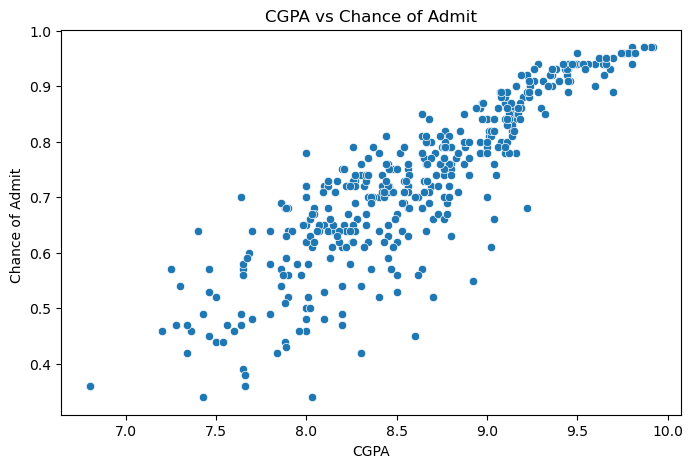

In [25]:
# Scatterplots
# 1. CGPA vs Chance of Admit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x='CGPA',
    y='Chance of Admit '
)

plt.title('CGPA vs Chance of Admit')
plt.show()

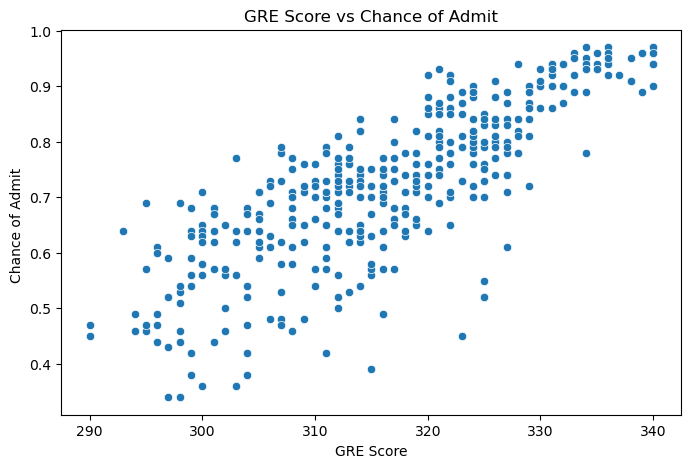

In [26]:
# 2.GRE Score vs Chance of Admit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x='GRE Score',
    y='Chance of Admit '
)

plt.title('GRE Score vs Chance of Admit')
plt.show()

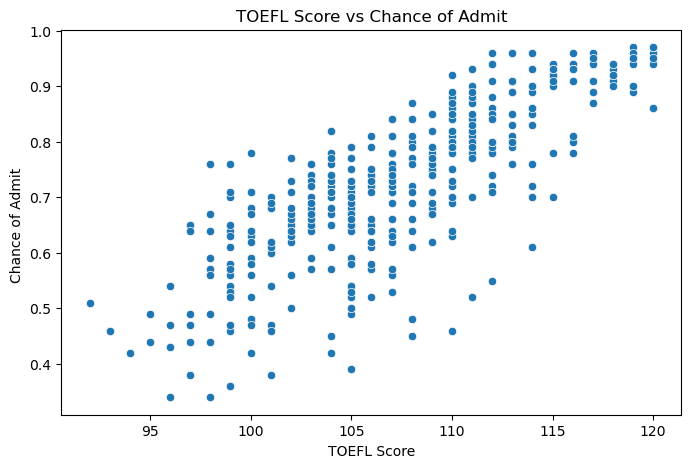

In [27]:
# TOEFL Score vs Chance of Admit.

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x='TOEFL Score',
    y='Chance of Admit '
)

plt.title('TOEFL Score vs Chance of Admit')
plt.show()

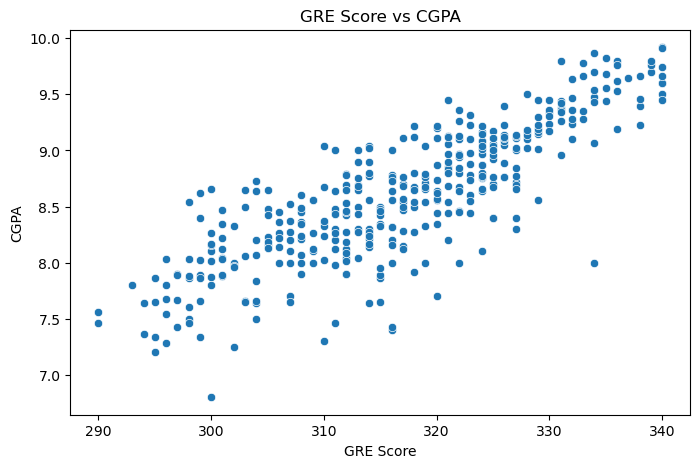

In [28]:
# GRE Score vs CGPA

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=analysis_df,
    x='GRE Score',
    y='CGPA'
)

plt.title('GRE Score vs CGPA')
plt.show()

In [33]:
# Outlier Treatment using IQR Capping

treatment_features = [
    'GRE Score',
    'TOEFL Score',
    'University Rating',
    'SOP',
    'LOR ',
    'CGPA'
]

treated_df = analysis_df.copy()

for column in treatment_features:
    Q1 = treated_df[column].quantile(0.25)
    Q3 = treated_df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    treated_df[column] = treated_df[column].clip(
        lower_bound,
        upper_bound
    )

print("Original shape:", analysis_df.shape)
print("Treated shape:", treated_df.shape)

Original shape: (400, 8)
Treated shape: (400, 8)


In [34]:
# Check whether values changed after treatment

for column in treatment_features:
    changed = (analysis_df[column] != treated_df[column]).sum()
    print(f"{column}: {changed} values capped")

GRE Score: 0 values capped
TOEFL Score: 0 values capped
University Rating: 0 values capped
SOP: 0 values capped
LOR : 1 values capped
CGPA: 1 values capped


### Task 3 Conclusion

Developed an outlier detection and treatment pipeline for the university admission dataset. Boxplots and scatterplots were used for visual inspection, while IQR and Z-score methods were applied for statistical outlier detection and comparison. The identified anomalous values were treated using IQR-based capping on selected continuous applicant features. This approach reduced the influence of extreme observations while preserving all dataset records, providing a cleaner dataset for subsequent machine learning model development.
